# Setup

In [ ]:
import shutil, os
if os.path.exists('e_network_inequality'):
    shutil.rmtree('e_network_inequality')

# !git clone https://github.com/IgnacioOQ/e_network_inequality
!git clone -b main https://github.com/IgnacioOQ/e_network_inequality

Cloning into 'e_network_inequality'...
remote: Enumerating objects: 2370, done.
remote: Counting objects: 100% (531/531), done.
remote: Compressing objects: 100% (340/340), done.
remote: Total 2370 (delta 256), reused 245 (delta 191), pack-reused 1839 (from 2)
Receiving objects: 100% (2370/2370), 142.54 MiB | 28.39 MiB/s, done.
Resolving deltas: 100% (1470/1470), done.
Updating files: 100% (87/87), done.


In [ ]:
!pip install dill

In [ ]:
%cd e_network_inequality

/content/e_network_inequality/e_network_inequality


In [ ]:
import sys, os
sys.path.insert(0, os.getcwd())

from utils.imports import *
from model.agents import BetaAgent, BayesAgent
from model.model import Model
from utils.network_utils import *
from networks.network_generation import *
from networks.variation_methods import *
from model.simulation_functions import *
from model.vectorized_simulation_functions import *
from functools import partial
import hashlib
import gc
from multiprocessing import get_context

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

dumping_path = '/content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/stop_condition_study/'
print("Current Directory:", dumping_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current Directory: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/stop_condition_study/


In [ ]:
def generate_parameters_here(_,G,method='randomization'):
    process_seed = int.from_bytes(os.urandom(4), byteorder='little')
    rd.seed(process_seed)
    # Randomly sample parameters for this group
    uncertainty = rd.uniform(.000001, .001)
    n_experiments = rd.randint(1000, 10000)
    # now we pick a random number
    # Capped at 1/3 to prevent "Sample larger than population" errors in equalize
    proportion_edges = rd.rand() * (1/3)
    # Do randomization
    num_edges = G.number_of_edges()
    if method == 'randomization':
      num_edges_to_randomize = int(num_edges * proportion_edges)
      modified_network = randomize_network(G, n_edges=num_edges_to_randomize)
    if method == 'equalize':
      num_edges_to_randomize = int(num_edges * proportion_edges)
      modified_network = equalize(G, num_edges_to_randomize)
    if method == 'densify':
      num_edges_to_add = int(num_edges * proportion_edges)
      modified_network = densify_fancy_speed_up(G,num_edges_to_add,target_degree_dist='original',keep_density_fixed=False)
    if method == 'densify_fixed':
      num_edges_to_add = int(num_edges * proportion_edges)
      modified_network = densify_fancy_speed_up(G,num_edges_to_add,target_degree_dist='uniform',keep_density_fixed=True)
    if method =='cluster':
      num_edges_to_add = int(num_edges * proportion_edges)
      modified_network = cluster_network(G,num_edges_to_add)
    if method =='decluster':
      num_edges_to_randomize = int(num_edges * proportion_edges)
      modified_network = decluster_network(G,num_edges_to_randomize)

    result = generate_parameters_aggregate(modified_network, uncertainty=uncertainty, n_experiments=n_experiments,
                                           p_rewiring=proportion_edges)
    result['uncertainty'] = uncertainty
    result['n_experiments'] = n_experiments
    result['proportion_edges'] = proportion_edges
    result['parameter_random_seed']= process_seed
    return result

# Study 0: Load Networks

In [ ]:
# ── Load Networks + Parallelization Setup ────────────────────────────────────
from model.vectorized_model import VectorizedModel
from model.vectorized_simulation_functions import run_vectorized_simulation_with_params
from functools import partial
from multiprocessing import Pool, cpu_count
import itertools
import pickle
import networkx as nx

num_cores = cpu_count()
print(f"Available CPU cores: {num_cores}")

with open('./networks/citation_data/pud_network.pkl', 'rb') as f:
    G_pud = pickle.load(f)
mapping = {node: idx for idx, node in enumerate(G_pud.nodes())}
G_pud_indexed = nx.relabel_nodes(G_pud, mapping)
print(f"PUD network: {G_pud_indexed.number_of_nodes()} nodes, {G_pud_indexed.number_of_edges()} edges")

with open('./networks/citation_data/tobacco_network.pkl', 'rb') as f:
    G_tobacco = pickle.load(f)
mapping = {node: idx for idx, node in enumerate(G_tobacco.nodes())}
G_tobacco_indexed = nx.relabel_nodes(G_tobacco, mapping)
print(f"Tobacco network: {G_tobacco_indexed.number_of_nodes()} nodes, {G_tobacco_indexed.number_of_edges()} edges")

with open('./networks/citation_data/ego_network.pkl', 'rb') as f:
    G_ego = pickle.load(f)
mapping = {node: idx for idx, node in enumerate(G_ego.nodes())}
G_ego_indexed = nx.relabel_nodes(G_ego, mapping)
print(f"Ego network: {G_ego_indexed.number_of_nodes()} nodes, {G_ego_indexed.number_of_edges()} edges")


Available CPU cores: 8
PUD network: 90 nodes, 160 edges
Tobacco network: 289 nodes, 1229 edges
Ego network: 503 nodes, 2933 edges


# Study: Compute Time and Truth Share Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from functools import partial
from multiprocessing import Pool
from tqdm.notebook import tqdm

N_EXPERIMENTS = 1000
UNCERTAINTY = 0.0001
N_RUNS = 100
MAX_STEPS = 100_000


In [ ]:
SNAPSHOT_INTERVAL = 5_000  # record every 5,000 steps

# Master seed for this study. Each call to run_compute_time_study spawns its
# own sub-sequence from master_ss, so seeds are statistically independent
# across (network, run) pairs. Each seed is also logged in result_dict.
from numpy.random import SeedSequence
MASTER_SEED = 20260513
master_ss = SeedSequence(MASTER_SEED)

def run_compute_time_study(network, network_label, output_prefix):
    print(f"=== Compute Time Study: {network_label} Network ===")
    print(f"    Parallelizing across {num_cores} CPU cores ({N_RUNS} runs total)")

    child_seeds = [int(s.generate_state(1)[0])
                   for s in master_ss.spawn(N_RUNS)]
    param_dicts = [
        {"network": network,
         "n_experiments": N_EXPERIMENTS,
         "uncertainty": UNCERTAINTY,
         "seed": cs}
        for cs in child_seeds
    ]

    wrapper = partial(
        run_vectorized_simulation_with_params,
        tolerance=1e-5,
        tolerance_stopping=False,
        tstep_stopping=True,
        number_of_steps=MAX_STEPS,
        show_bar=False,
        agent_type="beta",
        snapshot_interval=SNAPSHOT_INTERVAL,
    )

    start_time = time.time()

    with Pool(num_cores) as pool:
        results = list(tqdm(
            pool.imap_unordered(wrapper, param_dicts),
            total=N_RUNS,
            desc=f"[{network_label}] Running simulations",
        ))

    end_time = time.time()
    compute_time = end_time - start_time
    estimated_10k = compute_time / N_RUNS * 10_000
    print(f"  [{network_label}] Total compute time for {N_RUNS} runs: {compute_time:.2f} s ({compute_time/60:.2f} min)")
    print(f"  [{network_label}] Estimated compute time for 10,000 runs: {estimated_10k:.2f} s ({estimated_10k/60:.2f} min)")

    truth_shares = [r.get("share_of_correct_agents_at_convergence", 0) for r in results]
    mean_truth = np.mean(truth_shares)
    std_truth = np.std(truth_shares)

    print(f"  [{network_label}] Mean Truth Share: {mean_truth:.4f} (Std: {std_truth:.4f})")

    # Save results
    rows = [{"run": i, "truth_share": ts} for i, ts in enumerate(truth_shares)]
    df = pd.DataFrame(rows)
    df.to_csv(dumping_path + f"{output_prefix}_compute_time_results.csv", index=False)

    # Collect snapshots list from all runs
    all_snapshots = [r["snapshots"] for r in results if "snapshots" in r]

    return compute_time, mean_truth, std_truth, truth_shares, all_snapshots


In [ ]:
pud_time, pud_mean, pud_std, pud_shares, pud_snapshots = run_compute_time_study(G_pud_indexed, "PUD", "pud")
tobacco_time, tobacco_mean, tobacco_std, tobacco_shares, tobacco_snapshots = run_compute_time_study(G_tobacco_indexed, "Tobacco", "tobacco")
ego_time, ego_mean, ego_std, ego_shares, ego_snapshots = run_compute_time_study(G_ego_indexed, "Ego", "ego")


=== Compute Time Study: PUD Network ===
    Parallelizing across 8 CPU cores (100 runs total)


[PUD] Running simulations:   0%|          | 0/100 [00:00<?, ?it/s]

  [PUD] Total compute time for 100 runs: 469.87 s (7.83 min)
  [PUD] Estimated compute time for 10,000 runs: 46986.89 s (783.11 min)
  [PUD] Mean Truth Share: 0.6890 (Std: 0.1084)
=== Compute Time Study: Tobacco Network ===
    Parallelizing across 8 CPU cores (100 runs total)


[Tobacco] Running simulations:   0%|          | 0/100 [00:00<?, ?it/s]

  [Tobacco] Total compute time for 100 runs: 622.41 s (10.37 min)
  [Tobacco] Estimated compute time for 10,000 runs: 62241.36 s (1037.36 min)
  [Tobacco] Mean Truth Share: 0.8616 (Std: 0.0216)
=== Compute Time Study: Ego Network ===
    Parallelizing across 8 CPU cores (100 runs total)


[Ego] Running simulations:   0%|          | 0/100 [00:00<?, ?it/s]

  [Ego] Total compute time for 100 runs: 774.95 s (12.92 min)
  [Ego] Estimated compute time for 10,000 runs: 77495.45 s (1291.59 min)
  [Ego] Mean Truth Share: 0.9584 (Std: 0.1633)


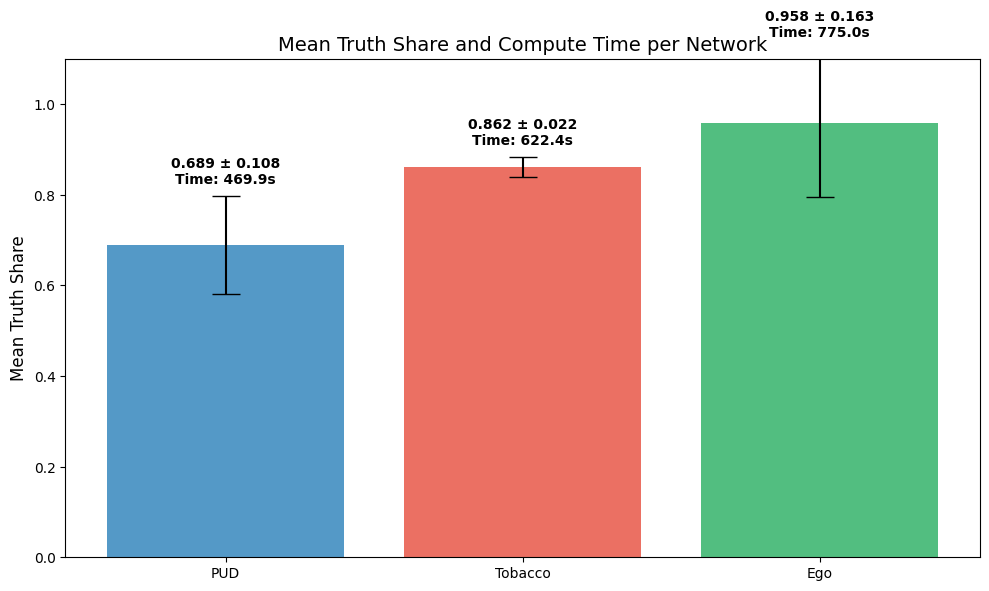

Plot saved to /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/stop_condition_study/compute_time_study_results.png


In [ ]:
networks = ["PUD", "Tobacco", "Ego"]
means = [pud_mean, tobacco_mean, ego_mean]
stds = [pud_std, tobacco_std, ego_std]
times = [pud_time, tobacco_time, ego_time]
fig, ax1 = plt.subplots(figsize=(10, 6))
bars = ax1.bar(networks, means, yerr=stds, capsize=10, color=['#2980b9', '#e74c3c', '#27ae60'], alpha=0.8)
ax1.set_ylabel('Mean Truth Share', fontsize=12)
ax1.set_title('Mean Truth Share and Compute Time per Network', fontsize=14)
ax1.set_ylim(0, 1.1)  # slightly above 1 for text
for i, v in enumerate(means):
    ax1.text(i, v + stds[i] + 0.02, f"{v:.3f} ± {stds[i]:.3f}\nTime: {times[i]:.1f}s", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plot_path = dumping_path + "compute_time_study_results.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved to {plot_path}")


## Snapshot Analysis: Belief Dynamics over Time

The following plots show the **average trajectory** across all 100 simulation runs for each network.

- **Left panel**: Mean truth share (± 1 SD) sampled every `SNAPSHOT_INTERVAL` steps.
- **Right panel**: Mean maximum absolute belief change (± 1 SD) on a log scale — a proxy for how quickly agents' beliefs have stabilised.


In [ ]:
def aggregate_snapshots(all_snapshots):
    """
    Given a list of snapshot dicts (one per run), returns:
        steps              : 1-D array of step indices
        mean_truth         : mean truth share at each step
        std_truth          : std of truth share at each step
        mean_max_change    : mean of max-abs-belief-change at each step
        std_max_change     : std of max-abs-belief-change at each step
    """
    steps = np.array(all_snapshots[0]['step'])
    # Stack truth shares: shape (n_runs, n_steps)
    truth_matrix = np.array([s['truth_share'] for s in all_snapshots])
    # Stack max belief changes: filter None (bayes runs)
    change_lists = [s['max_belief_change'] for s in all_snapshots
                    if None not in s['max_belief_change']]
    change_matrix = np.array(change_lists) if change_lists else None

    mean_truth = truth_matrix.mean(axis=0)
    std_truth  = truth_matrix.std(axis=0)

    if change_matrix is not None:
        mean_change = change_matrix.mean(axis=0)
        std_change  = change_matrix.std(axis=0)
    else:
        mean_change = std_change = None

    return steps, mean_truth, std_truth, mean_change, std_change


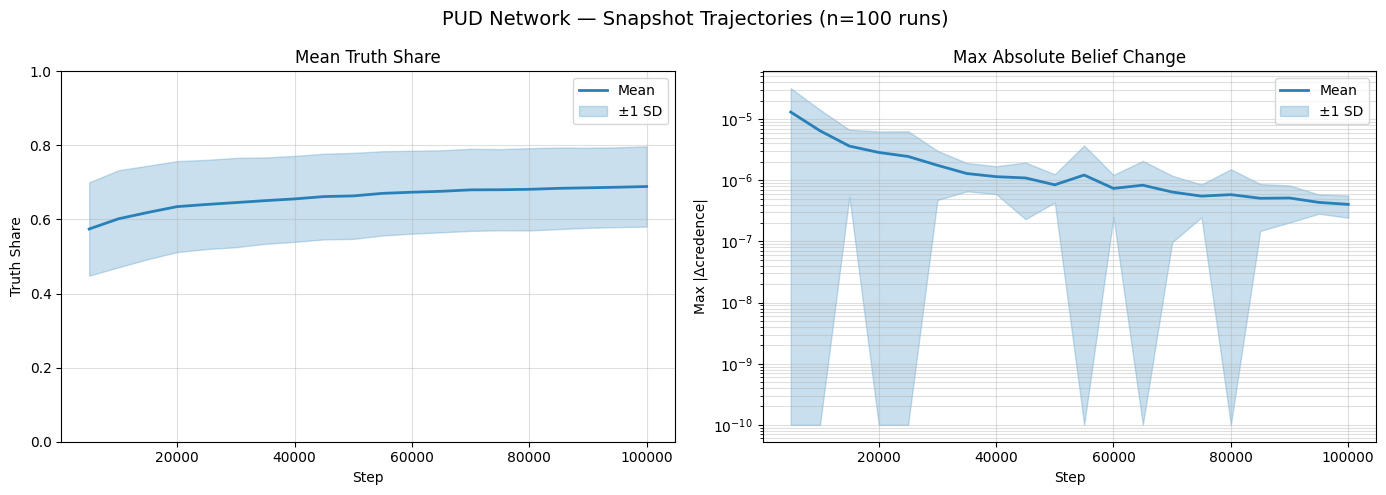

Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/stop_condition_study/pud_snapshot_trajectories.png


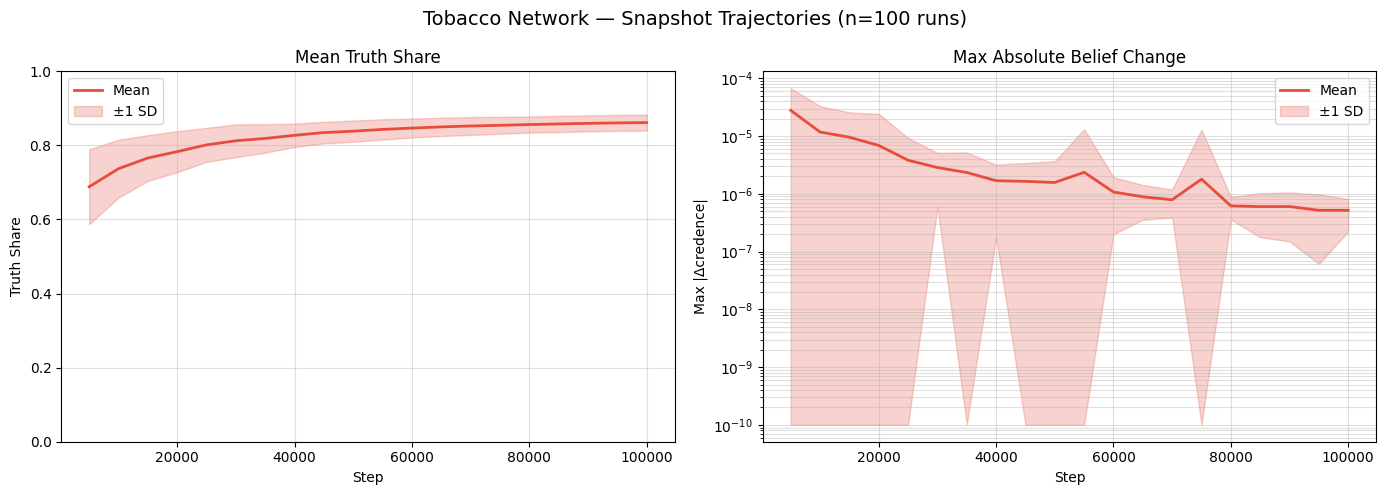

Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/stop_condition_study/tobacco_snapshot_trajectories.png


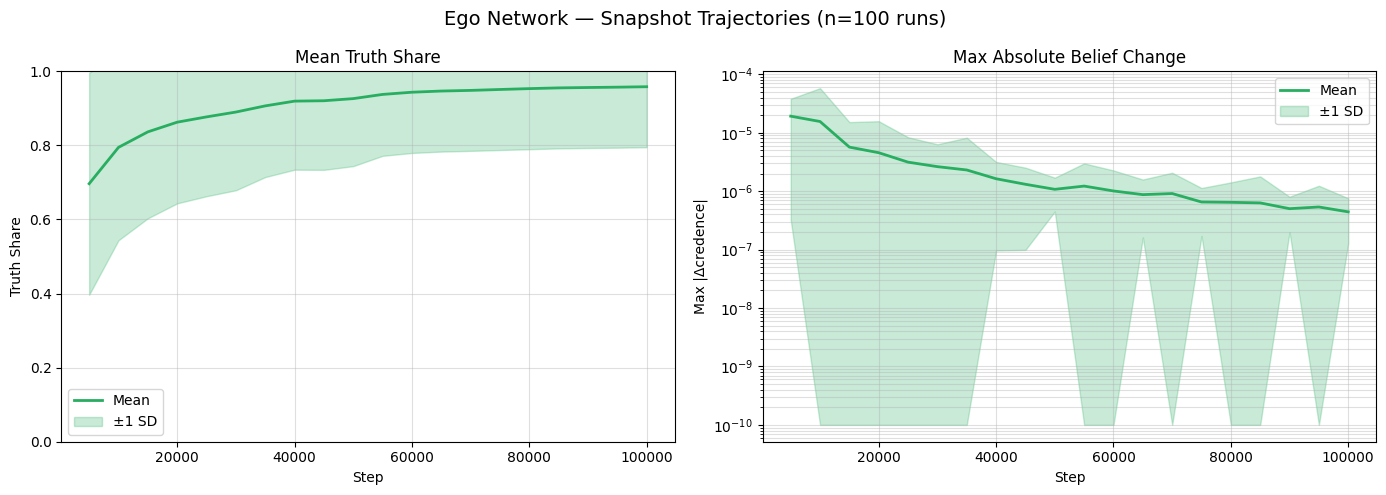

Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/stop_condition_study/ego_snapshot_trajectories.png


In [ ]:
# ── Per-network snapshot plots ─────────────────────────────────────────────
network_data = [
    ('PUD',     pud_snapshots,     '#2980b9'),
    ('Tobacco', tobacco_snapshots, '#e74c3c'),
    ('Ego',     ego_snapshots,     '#27ae60'),
]

for label, snaps, color in network_data:
    if not snaps:
        print(f'[{label}] No snapshots available.')
        continue

    steps, mt, st, mc, sc = aggregate_snapshots(snaps)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{label} Network — Snapshot Trajectories (n={len(snaps)} runs)', fontsize=14)

    # Left: truth share
    ax = axes[0]
    ax.plot(steps, mt, color=color, linewidth=2, label='Mean')
    ax.fill_between(steps, mt - st, mt + st, alpha=0.25, color=color, label='±1 SD')
    ax.set_title('Mean Truth Share')
    ax.set_xlabel('Step')
    ax.set_ylabel('Truth Share')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.4)

    # Right: max belief change
    ax = axes[1]
    if mc is not None:
        ax.plot(steps, mc, color=color, linewidth=2, label='Mean')
        ax.fill_between(steps, np.maximum(mc - sc, 1e-10), mc + sc,
                        alpha=0.25, color=color, label='±1 SD')
        ax.set_yscale('log')
        ax.set_title('Max Absolute Belief Change')
        ax.set_xlabel('Step')
        ax.set_ylabel('Max |Δcredence|')
        ax.legend()
        ax.grid(True, alpha=0.4, which='both')
    else:
        ax.set_visible(False)

    plt.tight_layout()
    plot_path = dumping_path + f"{label.lower()}_snapshot_trajectories.png"
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f'Saved: {plot_path}')


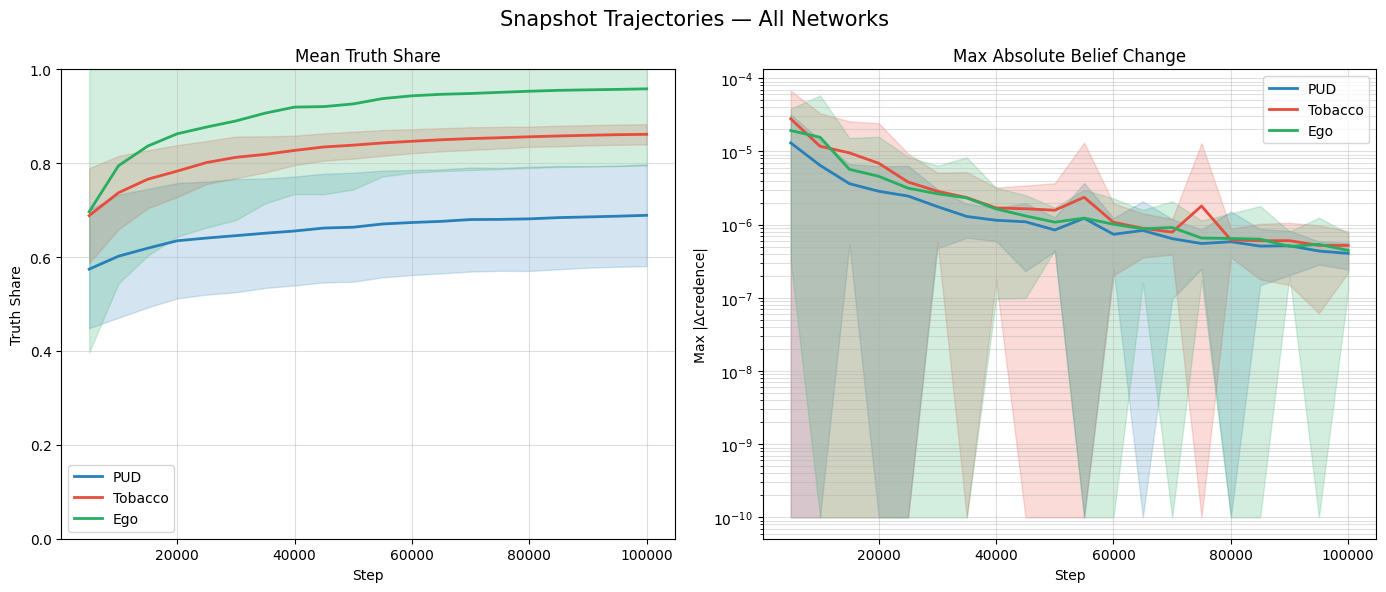

Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/stop_condition_study/all_networks_snapshot_trajectories.png


In [ ]:
# ── Combined comparison plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Snapshot Trajectories — All Networks', fontsize=15)

network_data = [
    ('PUD',     pud_snapshots,     '#2980b9'),
    ('Tobacco', tobacco_snapshots, '#e74c3c'),
    ('Ego',     ego_snapshots,     '#27ae60'),
]

for label, snaps, color in network_data:
    if not snaps:
        continue
    steps, mt, st, mc, sc = aggregate_snapshots(snaps)

    # Truth share
    axes[0].plot(steps, mt, color=color, linewidth=2, label=label)
    axes[0].fill_between(steps, mt - st, mt + st, alpha=0.2, color=color)

    # Max belief change
    if mc is not None:
        axes[1].plot(steps, mc, color=color, linewidth=2, label=label)
        axes[1].fill_between(steps, np.maximum(mc - sc, 1e-10), mc + sc,
                             alpha=0.2, color=color)

axes[0].set_title('Mean Truth Share')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Truth Share')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].set_title('Max Absolute Belief Change')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Max |Δcredence|')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.4, which='both')

plt.tight_layout()
plot_path = dumping_path + 'all_networks_snapshot_trajectories.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Saved: {plot_path}')


## Disconnect from Runtime

In [ ]:
from datetime import datetime
import pytz
from IPython.display import Javascript

# Get current time in New York
nyc_time = datetime.now(pytz.timezone('America/New_York'))
formatted_time = nyc_time.strftime('%Y-%m-%d %H:%M:%S %Z')

# Print and log
print(f"✅ Disconnected from runtime at: {formatted_time}")

# Disconnect Colab runtime
display(Javascript('google.colab.kernel.disconnect()'))

✅ Disconnected from runtime at: 2026-05-08 08:20:31 EDT


<IPython.core.display.Javascript object>